In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load untouched original CSV
df_original = pd.read_csv(r"orignal.csv")

# Convert Price safely
df_original["Price"] = pd.to_numeric(
    df_original["Price"],
    errors="coerce"
)

# Convert Date
df_original["Launch_date"] = pd.to_datetime(
    df_original["Launch_date"],
    format="mixed",
    errors="coerce",
    utc=True
)

# Create Year and Decade
df_original["Year"] = df_original["Launch_date"].dt.year
df_original["Decade"] = (df_original["Year"] // 10) * 10

print("Rows:", len(df_original))
print("Columns:", len(df_original.columns))

print("\nPrice missing:", df_original["Price"].isna().sum())
print("Price known:", df_original["Price"].notna().sum())

print("\nPrice summary:")
print(df_original["Price"].describe())

KeyError: 'Launch_date'

In [ ]:
# ============================================================
# FINANCIAL INVESTIGATION - ROUND 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If df is already your WhatsApp/team dataset, use it directly.
# Otherwise load your file:
df = pd.read_excel("csv_Final_Bosss.xlsx")


# ------------------------------------------------------------
# 1. PRICE DISTRIBUTION
# ------------------------------------------------------------

print("PRICE SUMMARY")
print(df["Price"].describe())


# ------------------------------------------------------------
# 2. PRICE QUANTILES
# ------------------------------------------------------------

print("\nPRICE QUANTILES")

print(
    df["Price"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
    )
)


# ------------------------------------------------------------
# 3. HOW MANY MISSIONS ARE VERY EXPENSIVE?
# ------------------------------------------------------------

thresholds = [50, 100, 200, 500, 1000, 2000, 5000]

print("\nPRICE THRESHOLDS")

for threshold in thresholds:

    count = (df["Price"] >= threshold).sum()

    percentage = (
        count / len(df) * 100
    )

    print(
        f"Price >= ${threshold}M : "
        f"{count} missions "
        f"({percentage:.2f}%)"
    )


# ------------------------------------------------------------
# 4. EXACT PRICE FREQUENCY
# ------------------------------------------------------------

print("\nMOST COMMON PRICE VALUES")

print(
    df["Price"]
    .value_counts()
    .head(15)
)


# ------------------------------------------------------------
# 5. PRICE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Price"],
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()


# ------------------------------------------------------------
# 6. LOG-SCALE DISTRIBUTION
# ------------------------------------------------------------
# Useful because Price is extremely skewed.

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(df["Price"]),
    bins=40
)

plt.xlabel("log(Price + 1)")
plt.ylabel("Number of Missions")
plt.title("Log-Scaled Distribution of Mission Prices")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(R"Space_Mission_Data_Final.csv")

price = df["Price"]

plt.figure(figsize=(10, 6))

plt.hist(price, bins=30)

plt.title("Distribution of Mission Prices")
plt.xlabel("Price ($ Million)")
plt.ylabel("Number of Missions")

plt.tight_layout()
plt.show()

# Analysis below graph
print("PRICE ANALYSIS")
print("=" * 50)

print(f"Total missions: {len(df):,}")
print(f"Mean price: ${price.mean():,.2f}M")
print(f"Median price: ${price.median():,.2f}M")
print(f"Minimum price: ${price.min():,.2f}M")
print(f"Maximum price: ${price.max():,.2f}M")

print("\nQuantiles:")
print(price.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]))

print("\nMost common prices:")
print(price.value_counts().head(10))

In [5]:
import pandas as pd
import numpy as np
import plotly.express as px

# ============================================================
# LOAD FINAL IMPUTED DATASET
# ============================================================

df = pd.read_csv(r"Space_Mission_Data_Final.csv")

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# ============================================================
# 1. CREATE PRICE BANDS
# ============================================================

def price_band(price):

    if price < 100:
        return "< $100M"

    elif price < 500:
        return "$100M–$500M"

    elif price < 1000:
        return "$500M–$1B"

    elif price < 2000:
        return "$1B–$2B"

    elif price < 5000:
        return "$2B–<$5B"

    else:
        return "$5B"


df["Price_Band"] = df["Price"].apply(price_band)


# ============================================================
# 2. INVESTIGATION: PRICE BAND DISTRIBUTION
# ============================================================

band_summary = (
    df["Price_Band"]
    .value_counts()
    .to_frame("Mission_Count")
)

band_summary["Percentage"] = (
    band_summary["Mission_Count"] /
    len(df) * 100
)

band_order = [
    "< $100M",
    "$100M–$500M",
    "$500M–$1B",
    "$1B–$2B",
    "$2B–<$5B",
    "$5B"
]

band_summary = band_summary.reindex(band_order).fillna(0)

print("\n" + "="*65)
print("INVESTIGATION 1 — PRICE BAND DISTRIBUTION")
print("="*65)

print(band_summary.round(2))


# ============================================================
# 3. INVESTIGATION: WHO DRIVES THE $5B CLUSTER?
# ============================================================

five_billion = df[df["Price"] == 5000]

five_b_org = (
    five_billion["Organisation"]
    .value_counts()
)

print("\n" + "="*65)
print("INVESTIGATION 2 — WHO DRIVES THE $5B CLUSTER?")
print("="*65)

print(f"Total $5B missions: {len(five_billion):,}")

print("\nOrganisations:")
print(five_b_org.head(15))


# ============================================================
# 4. INVESTIGATION: ORGANISATION × PRICE BAND
# ============================================================

org_band = pd.crosstab(
    df["Organisation"],
    df["Price_Band"]
)

org_band["Total"] = org_band.sum(axis=1)

org_band = org_band.sort_values(
    "Total",
    ascending=False
)

print("\n" + "="*65)
print("INVESTIGATION 3 — ORGANISATION × PRICE BAND")
print("="*65)

print(
    org_band[
        [
            "< $100M",
            "$100M–$500M",
            "$1B–$2B",
            "$5B",
            "Total"
        ]
    ].head(15)
)


# ============================================================
# 5. INVESTIGATION: DECADE PRICE BEHAVIOUR
# ============================================================

decade_summary = (
    df.groupby("Decade")["Price"]
    .agg(
        Mission_Count="count",
        Median_Price="median",
        Mean_Price="mean"
    )
    .reset_index()
)

print("\n" + "="*65)
print("INVESTIGATION 4 — PRICE BY DECADE")
print("="*65)

print(decade_summary.round(2))


# ============================================================
# 6. PREPARE SUNBURST
# ============================================================

# Keep major organisations visible.
# Everything else becomes "Other".

top_orgs = (
    df["Organisation"]
    .value_counts()
    .head(12)
    .index
)

sunburst_df = df.copy()

sunburst_df["Organisation_Display"] = np.where(
    sunburst_df["Organisation"].isin(top_orgs),
    sunburst_df["Organisation"],
    "Other Organisations"
)

sunburst_data = (
    sunburst_df
    .groupby(
        ["Price_Band", "Organisation_Display"],
        observed=True
    )
    .size()
    .reset_index(name="Mission_Count")
)

# ============================================================
# 7. CINEMATIC SUNBURST
# ============================================================

fig = px.sunburst(
    sunburst_data,
    path=["Price_Band", "Organisation_Display"],
    values="Mission_Count",
    title="Mission Price Structure: Price Band → Organisation",
)

fig.update_layout(
    title_font_size=22,
    height=750,
    margin=dict(t=80, l=10, r=10, b=10)
)

fig.update_traces(
    textinfo="label+percent parent",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Missions: %{value:,}<br>"
        "Share of parent: %{percentParent:.2%}"
        "<extra></extra>"
    )
)

fig.show()


# ============================================================
# 8. KEY FINDINGS BELOW GRAPH
# ============================================================

print("\n" + "="*65)
print("KEY PRICE FINDINGS")
print("="*65)

print(
    f"""
1. The Price distribution is highly concentrated.
   Median Price = ${df['Price'].median():,.0f}M
   Mean Price   = ${df['Price'].mean():,.0f}M

2. {len(df[df['Price'] == 5000]):,} missions are priced at $5B,
   representing {len(df[df['Price'] == 5000])/len(df)*100:.2f}% 
   of the entire dataset.

3. The $5B cluster is overwhelmingly associated with:
   {five_b_org.head(5).to_dict()}

4. Only a small number of distinct price values account for
   a very large proportion of all missions.

5. Therefore, the Price variable should not be interpreted
   simply through its mean. The distribution is strongly
   concentrated and influenced by repeated values.

6. Because these prices include imputed values, the observed
   concentration must also be interpreted in the context
   of the imputation methodology.
"""
)


INVESTIGATION 1 — PRICE BAND DISTRIBUTION
             Mission_Count  Percentage
Price_Band                            
< $100M             1743.0       40.31
$100M–$500M          740.0       17.11
$500M–$1B              0.0        0.00
$1B–$2B               64.0        1.48
$2B–<$5B               0.0        0.00
$5B                 1777.0       41.10

INVESTIGATION 2 — WHO DRIVES THE $5B CLUSTER?
Total $5B missions: 1,777

Organisations:
Organisation
RVSN USSR    1777
Name: count, dtype: int64

INVESTIGATION 3 — ORGANISATION × PRICE BAND
Price_Band        < $100M  $100M–$500M  $1B–$2B   $5B  Total
Organisation                                                
RVSN USSR               0            0        0  1777   1777
Arianespace            18          261        0     0    279
General Dynamics      251            0        0     0    251
CASC                  251            0        0     0    251
NASA                    0          139       64     0    203
VKS RF                201  


KEY PRICE FINDINGS

1. The Price distribution is highly concentrated.
   Median Price = $200M
   Mean Price   = $2,130M

2. 1,777 missions are priced at $5B,
   representing 41.10% 
   of the entire dataset.

3. The $5B cluster is overwhelmingly associated with:
   {'RVSN USSR': 1777}

4. Only a small number of distinct price values account for
   a very large proportion of all missions.

5. Therefore, the Price variable should not be interpreted
   simply through its mean. The distribution is strongly
   concentrated and influenced by repeated values.

6. Because these prices include imputed values, the observed
   concentration must also be interpreted in the context
   of the imputation methodology.



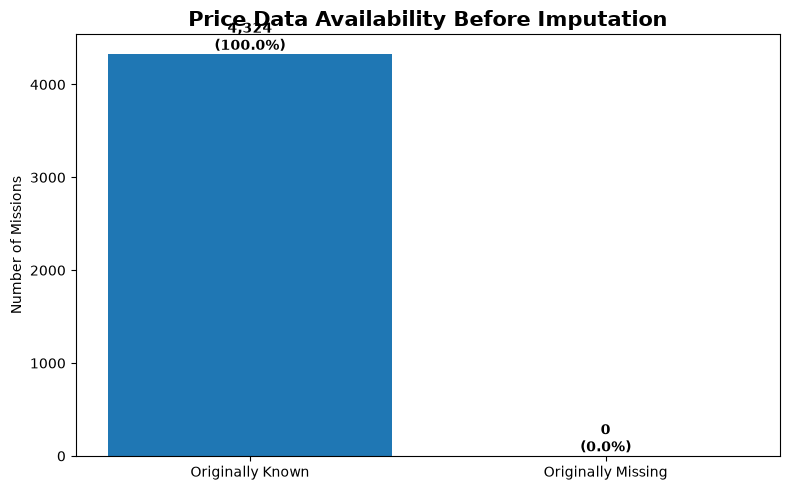

PRICE DATA AVAILABILITY
Total missions       : 4,324
Originally known     : 4,324 (100.00%)
Originally missing   : 0 (0.00%)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Original dataset - only for checking original Price availability
original = pd.read_csv(r"Space_Mission_Data_Final.csv")

# Convert Price safely
price_original = (
    original["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

price_original = pd.to_numeric(price_original, errors="coerce")

known = price_original.notna().sum()
missing = price_original.isna().sum()

labels = [
    "Originally Known",
    "Originally Missing"
]

values = [
    known,
    missing
]

percentages = [
    known / len(original) * 100,
    missing / len(original) * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title(
    "Price Data Availability Before Imputation",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Number of Missions")

for bar, value, pct in zip(bars, values, percentages):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f"{value:,}\n({pct:.1f}%)",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("PRICE DATA AVAILABILITY")
print("=" * 50)

print(f"Total missions       : {len(original):,}")
print(f"Originally known     : {known:,} ({known/len(original)*100:.2f}%)")
print(f"Originally missing   : {missing:,} ({missing/len(original)*100:.2f}%)")

personal info
objective
prev work experience
euducation
projects developed
skills and abelities
other experiences 